In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
day = pd.read_csv("C:/Users/harsh/Documents/infosys/Dataset exploration/day.csv")
hour = pd.read_csv("C:/Users/harsh/Documents/infosys/Dataset exploration/hour.csv")

print("DAY DATASET SHAPE:", day.shape)
print("HOUR DATASET SHAPE:", hour.shape)


DAY DATASET SHAPE: (731, 16)
HOUR DATASET SHAPE: (17379, 17)


In [4]:
print(day.head())
print(hour.head())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
   instant      dteday  se

In [5]:

print(day.info())
print(hour.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns

In [6]:
print("Duplicates in day:", day.duplicated().sum())
print("Duplicates in hour:", hour.duplicated().sum())

Duplicates in day: 0
Duplicates in hour: 0


In [7]:
print("DAY Missing Values:\n", day.isnull().sum())
print("HOUR Missing Values:\n", hour.isnull().sum())


DAY Missing Values:
 instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
HOUR Missing Values:
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


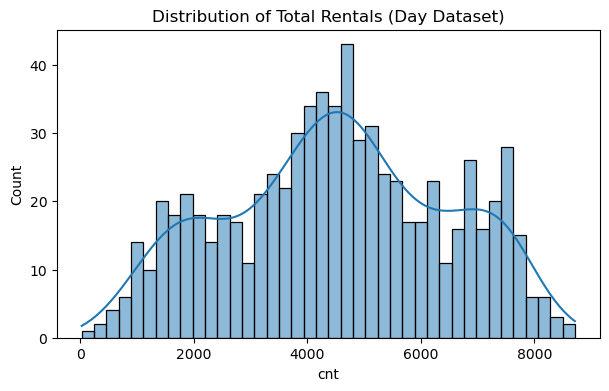

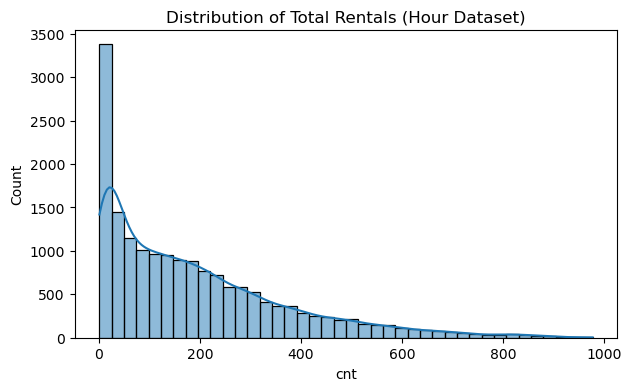

In [8]:
plt.figure(figsize=(7,4))
sns.histplot(day['cnt'], bins=40, kde=True)
plt.title("Distribution of Total Rentals (Day Dataset)")
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(hour['cnt'], bins=40, kde=True)
plt.title("Distribution of Total Rentals (Hour Dataset)")
plt.show()


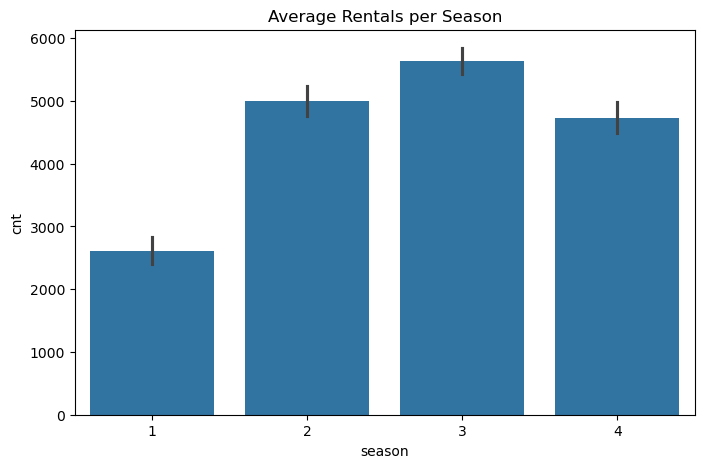

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(x='season', y='cnt', data=day, estimator=np.mean)
plt.title("Average Rentals per Season")
plt.show()



In [10]:
day['dteday'] = pd.to_datetime(day['dteday'])
hour['dteday'] = pd.to_datetime(hour['dteday'])

day[['dteday']].head()

,dteday
0,2011-01-01
1,2011-01-02
2,2011-01-03
3,2011-01-04
4,2011-01-05


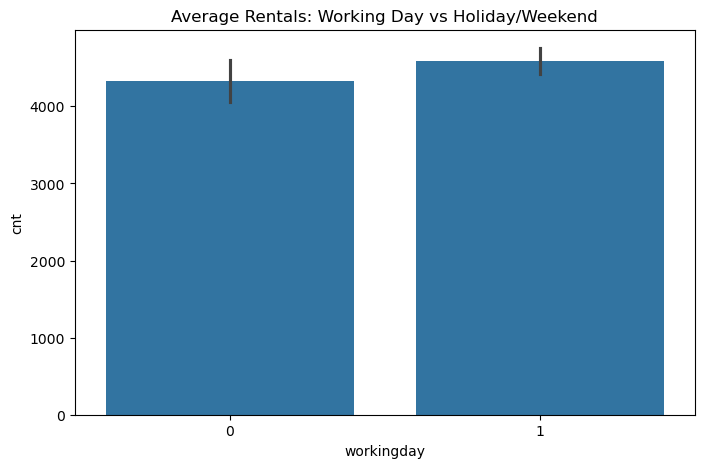

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(x='workingday', y='cnt', data=day, estimator=np.mean)
plt.title("Average Rentals: Working Day vs Holiday/Weekend")
plt.show()


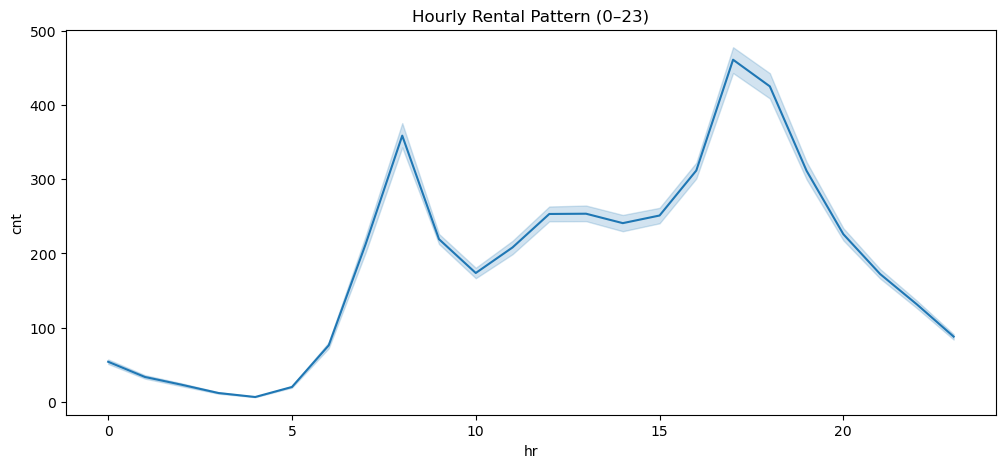

In [12]:
plt.figure(figsize=(12,5))
sns.lineplot(x='hr', y='cnt', data=hour, estimator='mean')
plt.title("Hourly Rental Pattern (0–23)")
plt.show()


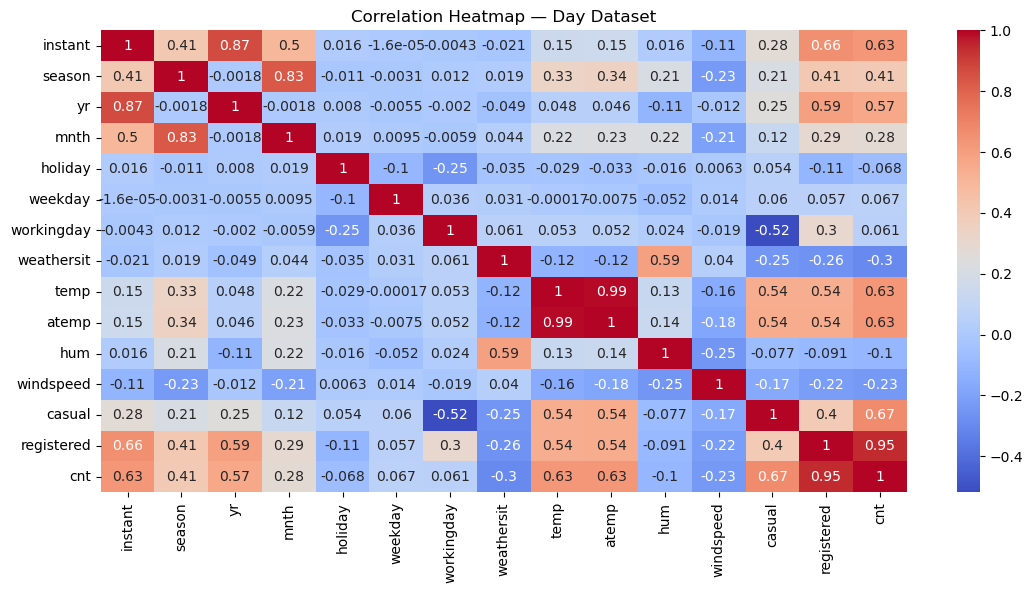

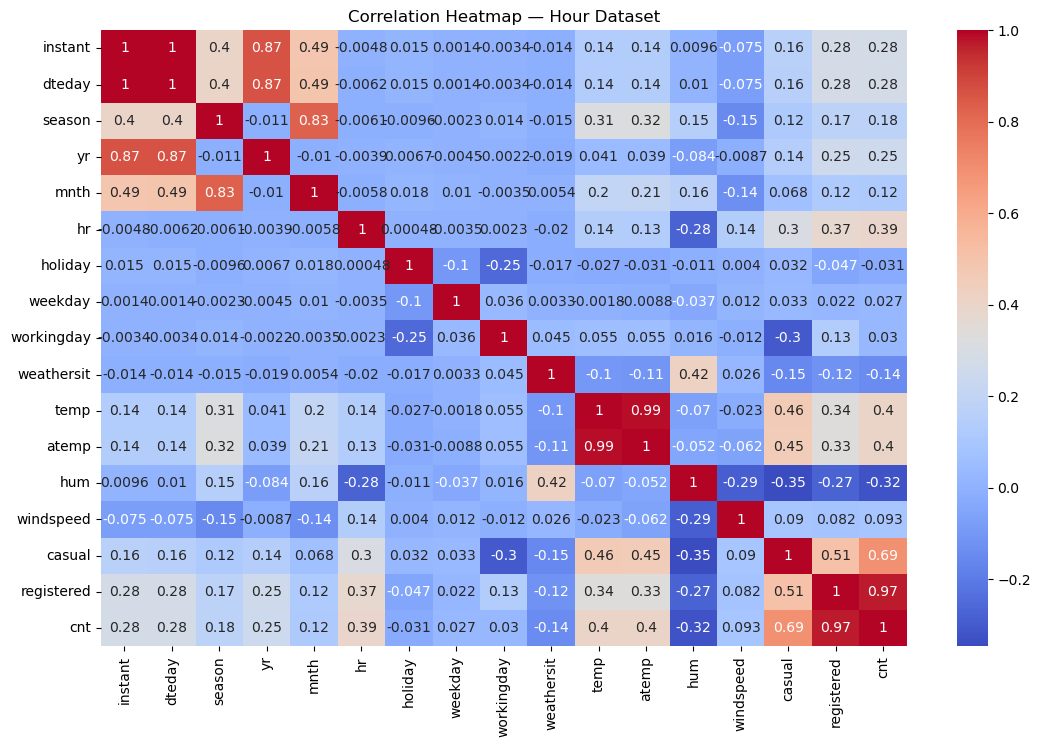

In [13]:
plt.figure(figsize=(13,6))

numeric_day = day.select_dtypes(include=['number'])

sns.heatmap(numeric_day.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap — Day Dataset")
plt.show()


plt.figure(figsize=(13,8))
sns.heatmap(hour.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap — Hour Dataset")
plt.show()


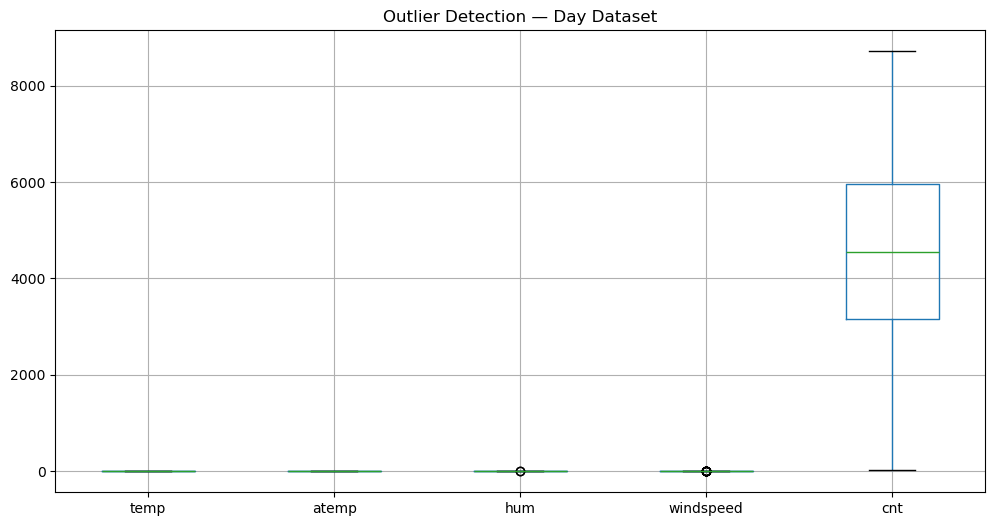

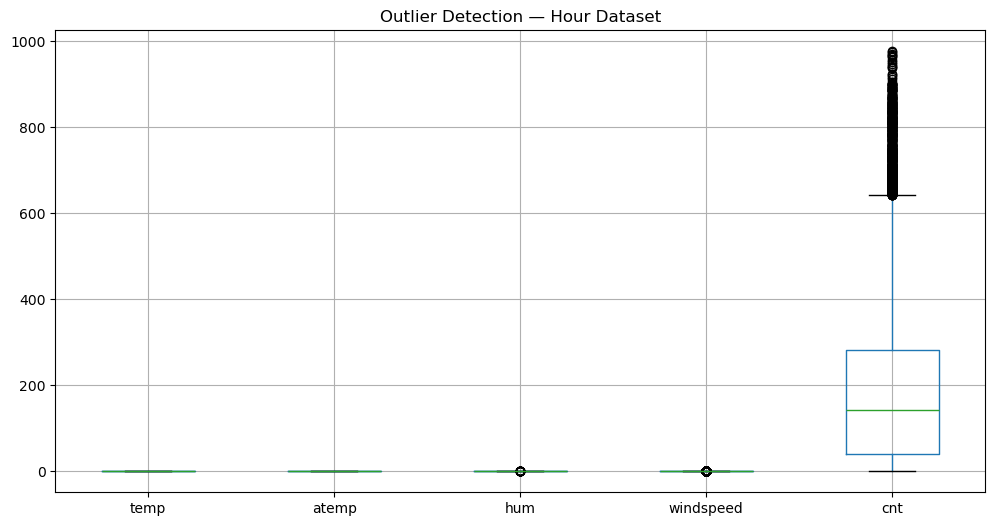

In [14]:
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']

plt.figure(figsize=(12,6))
day[numeric_cols].boxplot()
plt.title("Outlier Detection — Day Dataset")
plt.show()

plt.figure(figsize=(12,6))
hour[numeric_cols].boxplot()
plt.title("Outlier Detection — Hour Dataset")
plt.show()


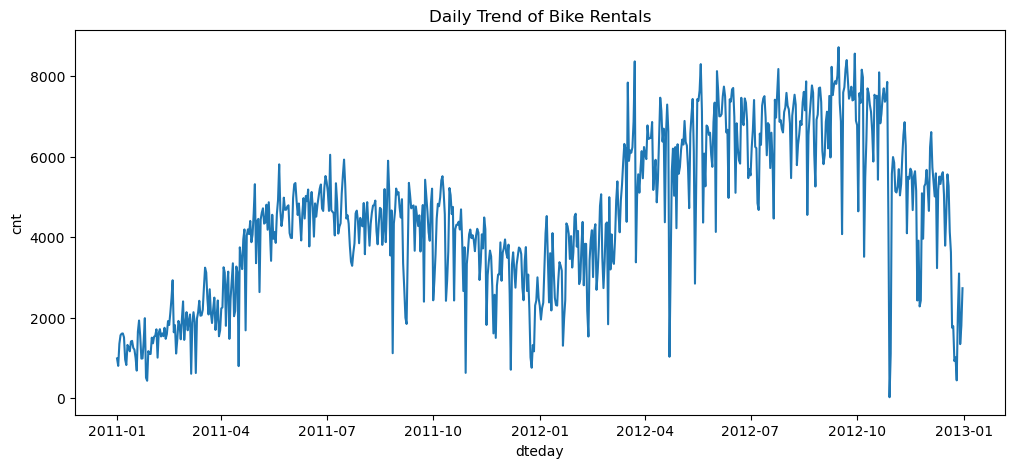

In [15]:
plt.figure(figsize=(12,5))
sns.lineplot(x='dteday', y='cnt', data=day)
plt.title("Daily Trend of Bike Rentals")
plt.show()


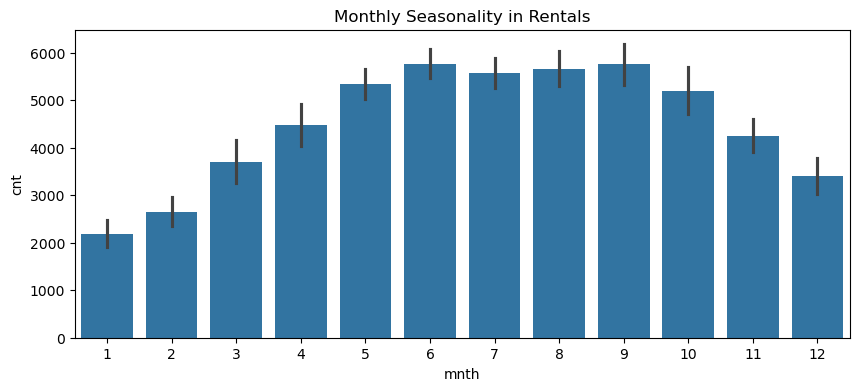

In [16]:
plt.figure(figsize=(10,4))
sns.barplot(x='mnth', y='cnt', data=day)
plt.title("Monthly Seasonality in Rentals")
plt.show()


In [32]:
day["zscore_cnt"] = (day["cnt"] - day["cnt"].mean()) / day["cnt"].std()

outliers = day[day["zscore_cnt"].abs() > 3]
print("Outliers detected:", len(outliers))
outliers.head()


Outliers detected: 0


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,day_of_year,week,is_weekend,zscore_cnt


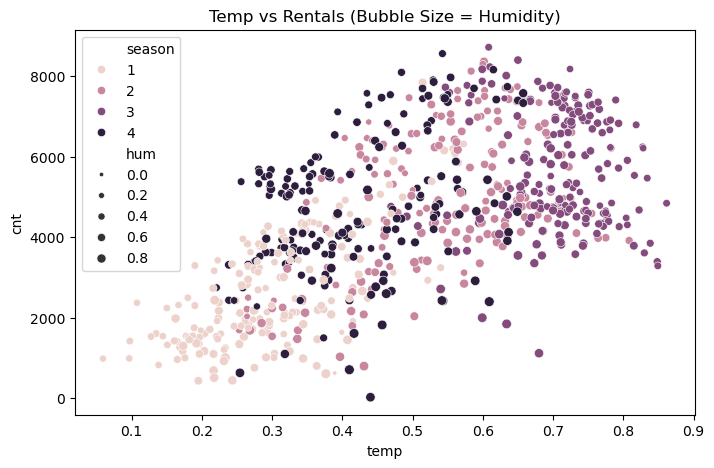

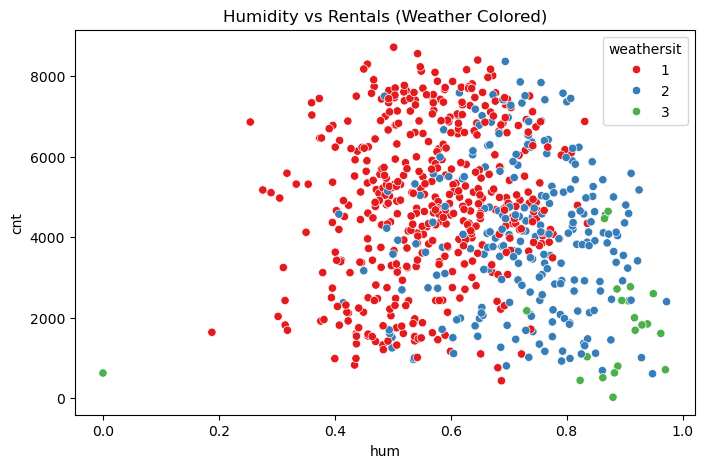

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=day, x="temp", y="cnt", size="hum", hue="season", sizes=(10,50))
plt.title("Temp vs Rentals (Bubble Size = Humidity)")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=day, x="hum", y="cnt", hue="weathersit", palette="Set1")
plt.title("Humidity vs Rentals (Weather Colored)")
plt.show()



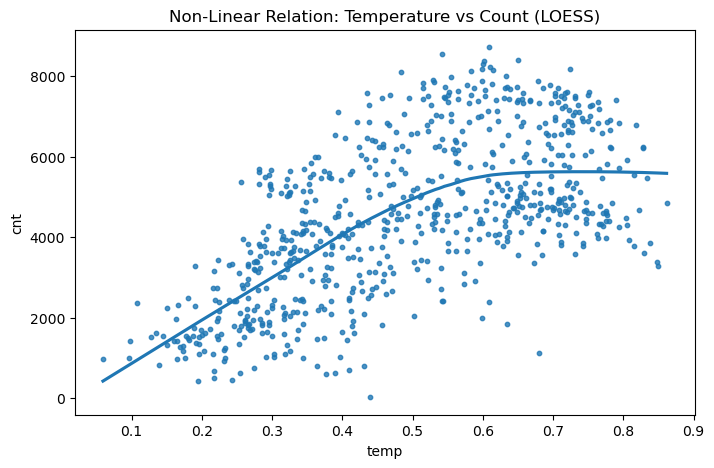

In [24]:
plt.figure(figsize=(8,5))
sns.regplot(data=day, x="temp", y="cnt", lowess=True, scatter_kws={"s":10})
plt.title("Non-Linear Relation: Temperature vs Count (LOESS)")
plt.show()


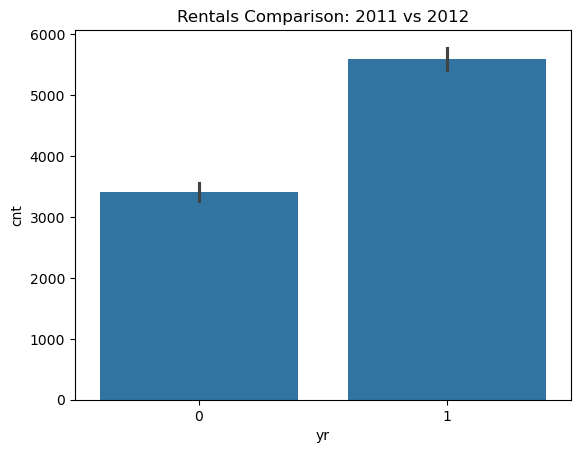

In [19]:
#Yearly Growth Suggests Model Should Capture Trend
sns.barplot(x='yr', y='cnt', data=day)
plt.title("Rentals Comparison: 2011 vs 2012")
plt.show()


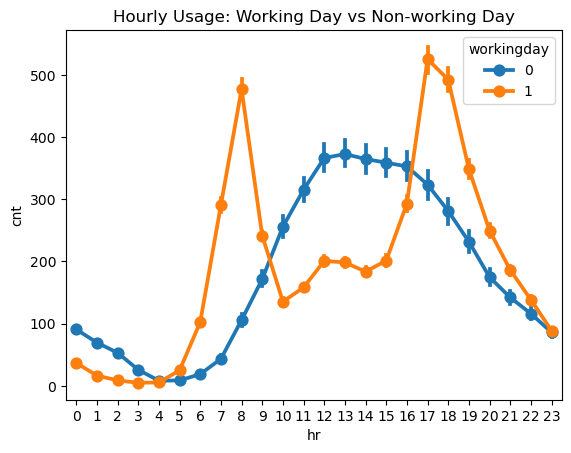

In [20]:
sns.pointplot(data=hour, x='hr', y='cnt', hue='workingday')
plt.title("Hourly Usage: Working Day vs Non-working Day")
plt.show()
